<a href="https://colab.research.google.com/github/vlhsilvia/TRABAJOS-PRACTICOS/blob/Silviamaster/Copia_de_Geotaller4_ConversionCSV_GEOJSON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geotaller 1: "Mapas Inteligentes con Python: Del CSV al GeoJSON en Minutos"

**Objetivo del Geotaller**:

Capacitar a los participantes en la transformación de datos tabulares (CSV) en datos geoespaciales (GeoJSON) utilizando Python y herramientas open source como pandas y geopandas. Al final del taller, los asistentes serán capaces de convertir cualquier dataset con coordenadas en un archivo geoespacial, visualizarlo en un mapa y exportarlo para su uso en herramientas GIS como QGIS o Google Earth.


* 📌 Público objetivo: Estudiantes y profesionales interesados en Ciencia de Datos Espaciales, GIS y Python.

## 1. Introducción

🔹 Presentación del Problema

**¿Por qué convertir CSV en GeoJSON?**
Muchos datasets incluyen información geoespacial en forma de coordenadas en columnas CSV, pero no están listos para su uso en herramientas GIS o mapas interactivos. En este taller, aprenderemos cómo transformar estos datos tabulares en un formato geoespacial estándar (GeoJSON) de manera rápida y sencilla.

**Caso de Uso**:

Vamos a trabajar con el dataset "Establecimientos Educativos Oficiales
Edu", que contiene información sobre las instituciones educativas en Colombia junto con sus coordenadas geográficas.

📍 Herramientas que Usaremos:

 *  Python como lenguaje de programación.
 *  Google Colab como entorno de trabajo sin instalación.
 *  Librerías clave:
      *  pandas para manejar datos tabulares.
      *  geopandas para convertir datos tabulares en datos espaciales.
      *  folium para visualizar los datos en mapas interactivos.

## 2. Desarrollo Práctico

💻 Transformación de CSV a GeoJSON en 5 Pasos Simples

🔹 Paso 1: Carga y Exploración del CSV

In [ ]:
# Importación de librerías
import pandas as pd
import geopandas as gpd
import folium
from folium import plugins
import matplotlib.pyplot as plt

In [ ]:
path1 = '/content/Establecimientos_Educativos_Oficiales_20250301.csv'
df = pd.read_csv(path1)  # Especificar encoding si es necesario
df.tail()

,mpio,dane,tipo,nombre,grados,zona,direccion,rector,telefono,email,JORNADAS,GEOREFERENCIACION,Nueva columna georreferenciada
65,SANTUARIO,266687000331,INSTITUCION EDUCATIVA,CE NUESTRA SEÑORA DEL ROSARIO,"0,1,2,3,4,5,6,7,8,9,10,11,21,22",RURAL,CGTO PERALONSO,GUILLERMO LEON BENJUMEA OCAMPO,3113452827,grie.senorarosariosantuario@risaralda.gov.co,"MAÑANA,ÚNICA,NOCTURNA,FIN DE SEMANA","(4.9877959, -75.9372639)",POINT (-75.9372639 4.9877959)
66,MARSELLA,266440000517,CENTRO EDUCATIVO,IE WAARRARA DEE,NaN,RURAL,CGTO ALTO CAUCA,RUBEN DARIO GUASARABE DREGAMA,NaN,grie.alto.cauca@risaralda.gov.co,"MAÑANA,NOCTURNA,FIN DE SEMANA","(4.9923788, -75.7452717)",POINT (-75.7452717 4.9923788)
67,MISTRATÓ,266456000304,CENTRO EDUCATIVO,IE RIO MISTRATO,NaN,RURAL,VDA RIO MISTRATO.,ABELARDO NARIQUIAZA BERNAZA,3175161195,grie.riomistrato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA","(5.388681, -76.037137)",POINT (-76.037137 5.388681)
68,PUEBLO RICO,266572000311,CENTRO EDUCATIVO,CE CIATO,NaN,RURAL,VDA CIATO,MARIA DOLMAN GALLEGO LOPEZ,3175114484,grie.ciato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA","(5.1930673, -76.0044987)",POINT (-76.0044987 5.1930673)
69,SANTUARIO,266687000501,CENTRO EDUCATIVO,CE ALTO PEÑAS BLANCAS,NaN,RURAL,VDA ALTO PEÑAS BLANCAS,NUBIA MARINA BEDOYA POLOCHE,3122372710,grie.altopenasblancas@risaralda.gov.co,"MAÑANA,ÚNICA","(5.0156727, -76.0041903)",POINT (-76.0041903 5.0156727)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   mpio                            70 non-null     object
 1   dane                            70 non-null     int64 
 2   tipo                            70 non-null     object
 3   nombre                          70 non-null     object
 4   grados                          66 non-null     object
 5   zona                            70 non-null     object
 6   direccion                       70 non-null     object
 7   rector                          70 non-null     object
 8   telefono                        68 non-null     object
 9   email                           70 non-null     object
 10  JORNADAS                        70 non-null     object
 11  GEOREFERENCIACION               58 non-null     object
 12  Nueva columna georreferenciada  58 non-null     obje

🔹 Paso 2: Limpieza y Preparación de datos

✅ A partir de aquí nos vamos a trazar tres objetivos para hacer una correcta limpieza de los datos:

1. Verificar que el dataset contiene columnas de latitud y longitud.

2. Identificar posibles inconsistencias o valores faltantes en dichas columnas.

3. Verificar que estas columnas estén siendo reconocidas en formato *float*

In [ ]:
df.columns

Index(['mpio', 'dane', 'tipo', 'nombre', 'grados', 'zona', 'direccion',
       'rector', 'telefono', 'email', 'JORNADAS', 'GEOREFERENCIACION',
       'Nueva columna georreferenciada'],
      dtype='object')

**Verificar que el dataset contiene columnas de latitud y longitud.**

In [ ]:
df[['GEOREFERENCIACION', 'Nueva columna georreferenciada']]

,GEOREFERENCIACION,Nueva columna georreferenciada
0,"(5.3531604 ,-76.1317372)",POINT (-76.1317372 5.3531604)
1,"(5.164724, -75.8624493)",POINT (-75.8624493 5.164724)
2,"(5.326591, -75.7821979)",POINT (-75.7821979 5.326591)
3,"(4.8667242, -75.6292786)",POINT (-75.6292786 4.8667242)
4,"(4.9933007, -75.9835117)",POINT (-75.9835117 4.9933007)
...,...,...
65,"(4.9877959, -75.9372639)",POINT (-75.9372639 4.9877959)
66,"(4.9923788, -75.7452717)",POINT (-75.7452717 4.9923788)
67,"(5.388681, -76.037137)",POINT (-76.037137 5.388681)
68,"(5.1930673, -76.0044987)",POINT (-76.0044987 5.1930673)


**Identificar posibles inconsistencias o valores faltantes en dichas columnas.**

In [ ]:
#Verifuquemos que hayan valores nulos
df['GEOREFERENCIACION'].isnull().sum()


12

In [ ]:
# Los eliminamos y hacemos un reseteo del index del dataFrame de pandas
df_NotNull = df.dropna(subset=['GEOREFERENCIACION'])
#Resteamos el index
df_NotNull = df_NotNull.reset_index(drop=True)

In [ ]:
df_NotNull.tail()

,mpio,dane,tipo,nombre,grados,zona,direccion,rector,telefono,email,JORNADAS,GEOREFERENCIACION,Nueva columna georreferenciada
53,SANTUARIO,266687000331,INSTITUCION EDUCATIVA,CE NUESTRA SEÑORA DEL ROSARIO,"0,1,2,3,4,5,6,7,8,9,10,11,21,22",RURAL,CGTO PERALONSO,GUILLERMO LEON BENJUMEA OCAMPO,3113452827,grie.senorarosariosantuario@risaralda.gov.co,"MAÑANA,ÚNICA,NOCTURNA,FIN DE SEMANA","(4.9877959, -75.9372639)",POINT (-75.9372639 4.9877959)
54,MARSELLA,266440000517,CENTRO EDUCATIVO,IE WAARRARA DEE,NaN,RURAL,CGTO ALTO CAUCA,RUBEN DARIO GUASARABE DREGAMA,NaN,grie.alto.cauca@risaralda.gov.co,"MAÑANA,NOCTURNA,FIN DE SEMANA","(4.9923788, -75.7452717)",POINT (-75.7452717 4.9923788)
55,MISTRATÓ,266456000304,CENTRO EDUCATIVO,IE RIO MISTRATO,NaN,RURAL,VDA RIO MISTRATO.,ABELARDO NARIQUIAZA BERNAZA,3175161195,grie.riomistrato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA","(5.388681, -76.037137)",POINT (-76.037137 5.388681)
56,PUEBLO RICO,266572000311,CENTRO EDUCATIVO,CE CIATO,NaN,RURAL,VDA CIATO,MARIA DOLMAN GALLEGO LOPEZ,3175114484,grie.ciato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA","(5.1930673, -76.0044987)",POINT (-76.0044987 5.1930673)
57,SANTUARIO,266687000501,CENTRO EDUCATIVO,CE ALTO PEÑAS BLANCAS,NaN,RURAL,VDA ALTO PEÑAS BLANCAS,NUBIA MARINA BEDOYA POLOCHE,3122372710,grie.altopenasblancas@risaralda.gov.co,"MAÑANA,ÚNICA","(5.0156727, -76.0041903)",POINT (-76.0041903 5.0156727)


In [ ]:
print(f""" Pasamos de  {len(df)} registros
 a {len(df_NotNull)} con la depuración por valores nulos """)

 Pasamos de  70 registros
 a 58 con la depuración por valores nulos 


Previo a esto haremos un paso intermedio:  Ahora lo que haremos será crear dos nuevas columnas:

* Latitud
* Longitud

In [ ]:
#Crea las columnas de latitud y longitud a partir de la información de la columna 'GEOREFERENCIACION'
df_NotNull[['latitud', 'longitud']] = df_NotNull['GEOREFERENCIACION'].str.split(',', expand=True)

In [ ]:
#Eliminamos paréntesis de las columnas de latitud y longitud
df_NotNull['latitud'] = df_NotNull['latitud'].str.replace('(', '')
df_NotNull['longitud'] = df_NotNull['longitud'].str.replace(')', '')

In [ ]:
df_NotNull.tail()

,mpio,dane,tipo,nombre,grados,zona,direccion,rector,telefono,email,JORNADAS,GEOREFERENCIACION,Nueva columna georreferenciada,latitud,longitud
53,SANTUARIO,266687000331,INSTITUCION EDUCATIVA,CE NUESTRA SEÑORA DEL ROSARIO,"0,1,2,3,4,5,6,7,8,9,10,11,21,22",RURAL,CGTO PERALONSO,GUILLERMO LEON BENJUMEA OCAMPO,3113452827,grie.senorarosariosantuario@risaralda.gov.co,"MAÑANA,ÚNICA,NOCTURNA,FIN DE SEMANA","(4.9877959, -75.9372639)",POINT (-75.9372639 4.9877959),4.9877959,-75.9372639
54,MARSELLA,266440000517,CENTRO EDUCATIVO,IE WAARRARA DEE,NaN,RURAL,CGTO ALTO CAUCA,RUBEN DARIO GUASARABE DREGAMA,NaN,grie.alto.cauca@risaralda.gov.co,"MAÑANA,NOCTURNA,FIN DE SEMANA","(4.9923788, -75.7452717)",POINT (-75.7452717 4.9923788),4.9923788,-75.7452717
55,MISTRATÓ,266456000304,CENTRO EDUCATIVO,IE RIO MISTRATO,NaN,RURAL,VDA RIO MISTRATO.,ABELARDO NARIQUIAZA BERNAZA,3175161195,grie.riomistrato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA","(5.388681, -76.037137)",POINT (-76.037137 5.388681),5.388681,-76.037137
56,PUEBLO RICO,266572000311,CENTRO EDUCATIVO,CE CIATO,NaN,RURAL,VDA CIATO,MARIA DOLMAN GALLEGO LOPEZ,3175114484,grie.ciato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA","(5.1930673, -76.0044987)",POINT (-76.0044987 5.1930673),5.1930673,-76.0044987
57,SANTUARIO,266687000501,CENTRO EDUCATIVO,CE ALTO PEÑAS BLANCAS,NaN,RURAL,VDA ALTO PEÑAS BLANCAS,NUBIA MARINA BEDOYA POLOCHE,3122372710,grie.altopenasblancas@risaralda.gov.co,"MAÑANA,ÚNICA","(5.0156727, -76.0041903)",POINT (-76.0041903 5.0156727),5.0156727,-76.0041903


Además de esto, eliminamos las columnas que ya no nos sirven:

- 'GEOREFERENCIACION'
-  'Nueva columna georreferenciada'

In [ ]:
df_NotNull.columns

Index(['mpio', 'dane', 'tipo', 'nombre', 'grados', 'zona', 'direccion',
       'rector', 'telefono', 'email', 'JORNADAS', 'GEOREFERENCIACION',
       'Nueva columna georreferenciada', 'latitud', 'longitud'],
      dtype='object')

Esto lo podemos hacer usando estructuras de datos en Python, como las *listas*

In [ ]:
columnas = ['GEOREFERENCIACION', 'Nueva columna georreferenciada']

df_NotNull.drop(columns=columnas, inplace=True)
#Resetea el index
df_NotNull = df_NotNull.reset_index(drop=True)

In [ ]:
df_NotNull.tail()

,mpio,dane,tipo,nombre,grados,zona,direccion,rector,telefono,email,JORNADAS,latitud,longitud
53,SANTUARIO,266687000331,INSTITUCION EDUCATIVA,CE NUESTRA SEÑORA DEL ROSARIO,"0,1,2,3,4,5,6,7,8,9,10,11,21,22",RURAL,CGTO PERALONSO,GUILLERMO LEON BENJUMEA OCAMPO,3113452827,grie.senorarosariosantuario@risaralda.gov.co,"MAÑANA,ÚNICA,NOCTURNA,FIN DE SEMANA",4.9877959,-75.9372639
54,MARSELLA,266440000517,CENTRO EDUCATIVO,IE WAARRARA DEE,NaN,RURAL,CGTO ALTO CAUCA,RUBEN DARIO GUASARABE DREGAMA,NaN,grie.alto.cauca@risaralda.gov.co,"MAÑANA,NOCTURNA,FIN DE SEMANA",4.9923788,-75.7452717
55,MISTRATÓ,266456000304,CENTRO EDUCATIVO,IE RIO MISTRATO,NaN,RURAL,VDA RIO MISTRATO.,ABELARDO NARIQUIAZA BERNAZA,3175161195,grie.riomistrato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA",5.388681,-76.037137
56,PUEBLO RICO,266572000311,CENTRO EDUCATIVO,CE CIATO,NaN,RURAL,VDA CIATO,MARIA DOLMAN GALLEGO LOPEZ,3175114484,grie.ciato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA",5.1930673,-76.0044987
57,SANTUARIO,266687000501,CENTRO EDUCATIVO,CE ALTO PEÑAS BLANCAS,NaN,RURAL,VDA ALTO PEÑAS BLANCAS,NUBIA MARINA BEDOYA POLOCHE,3122372710,grie.altopenasblancas@risaralda.gov.co,"MAÑANA,ÚNICA",5.0156727,-76.0041903


In [ ]:
df.columns

Index(['mpio', 'dane', 'tipo', 'nombre', 'grados', 'zona', 'direccion',
       'rector', 'telefono', 'email', 'JORNADAS', 'GEOREFERENCIACION',
       'Nueva columna georreferenciada'],
      dtype='object')

**Verificar que estas columnas estén siendo reconocidas en formato float**

In [ ]:
df_NotNull.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   mpio       58 non-null     object
 1   dane       58 non-null     int64 
 2   tipo       58 non-null     object
 3   nombre     58 non-null     object
 4   grados     54 non-null     object
 5   zona       58 non-null     object
 6   direccion  58 non-null     object
 7   rector     58 non-null     object
 8   telefono   56 non-null     object
 9   email      58 non-null     object
 10  JORNADAS   58 non-null     object
 11  latitud    58 non-null     object
 12  longitud   58 non-null     object
dtypes: int64(1), object(12)
memory usage: 6.0+ KB


In [ ]:
#Convertimos las columnas latitud y longitud a float
df_NotNull['latitud'] = df_NotNull['latitud'].astype(float)
df_NotNull['longitud'] = df_NotNull['longitud'].astype(float)

In [ ]:
df_NotNull.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mpio       58 non-null     object 
 1   dane       58 non-null     int64  
 2   tipo       58 non-null     object 
 3   nombre     58 non-null     object 
 4   grados     54 non-null     object 
 5   zona       58 non-null     object 
 6   direccion  58 non-null     object 
 7   rector     58 non-null     object 
 8   telefono   56 non-null     object 
 9   email      58 non-null     object 
 10  JORNADAS   58 non-null     object 
 11  latitud    58 non-null     float64
 12  longitud   58 non-null     float64
dtypes: float64(2), int64(1), object(10)
memory usage: 6.0+ KB


🔹 Paso 3: Conversión a GeoDataFrame

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# Crear geometría de puntos con latitud y longitud
df_NotNull['geometry'] = df_NotNull.apply(lambda row: Point(row['longitud'], row['latitud']), axis=1)
df_NotNull.tail()

,mpio,dane,tipo,nombre,grados,zona,direccion,rector,telefono,email,JORNADAS,latitud,longitud,geometry
53,SANTUARIO,266687000331,INSTITUCION EDUCATIVA,CE NUESTRA SEÑORA DEL ROSARIO,"0,1,2,3,4,5,6,7,8,9,10,11,21,22",RURAL,CGTO PERALONSO,GUILLERMO LEON BENJUMEA OCAMPO,3113452827,grie.senorarosariosantuario@risaralda.gov.co,"MAÑANA,ÚNICA,NOCTURNA,FIN DE SEMANA",4.987796,-75.937264,POINT (-75.9372639 4.9877959)
54,MARSELLA,266440000517,CENTRO EDUCATIVO,IE WAARRARA DEE,NaN,RURAL,CGTO ALTO CAUCA,RUBEN DARIO GUASARABE DREGAMA,NaN,grie.alto.cauca@risaralda.gov.co,"MAÑANA,NOCTURNA,FIN DE SEMANA",4.992379,-75.745272,POINT (-75.7452717 4.9923788)
55,MISTRATÓ,266456000304,CENTRO EDUCATIVO,IE RIO MISTRATO,NaN,RURAL,VDA RIO MISTRATO.,ABELARDO NARIQUIAZA BERNAZA,3175161195,grie.riomistrato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA",5.388681,-76.037137,POINT (-76.037137 5.388681)
56,PUEBLO RICO,266572000311,CENTRO EDUCATIVO,CE CIATO,NaN,RURAL,VDA CIATO,MARIA DOLMAN GALLEGO LOPEZ,3175114484,grie.ciato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA",5.193067,-76.004499,POINT (-76.0044987 5.1930673)
57,SANTUARIO,266687000501,CENTRO EDUCATIVO,CE ALTO PEÑAS BLANCAS,NaN,RURAL,VDA ALTO PEÑAS BLANCAS,NUBIA MARINA BEDOYA POLOCHE,3122372710,grie.altopenasblancas@risaralda.gov.co,"MAÑANA,ÚNICA",5.015673,-76.004190,POINT (-76.0041903 5.0156727)


In [ ]:
# Convertir a GeoDataFrame
gdf = gpd.GeoDataFrame(df_NotNull, geometry="geometry", crs="EPSG:4326")

gdf.tail()

,mpio,dane,tipo,nombre,grados,zona,direccion,rector,telefono,email,JORNADAS,latitud,longitud,geometry
53,SANTUARIO,266687000331,INSTITUCION EDUCATIVA,CE NUESTRA SEÑORA DEL ROSARIO,"0,1,2,3,4,5,6,7,8,9,10,11,21,22",RURAL,CGTO PERALONSO,GUILLERMO LEON BENJUMEA OCAMPO,3113452827,grie.senorarosariosantuario@risaralda.gov.co,"MAÑANA,ÚNICA,NOCTURNA,FIN DE SEMANA",4.987796,-75.937264,POINT (-75.93726 4.9878)
54,MARSELLA,266440000517,CENTRO EDUCATIVO,IE WAARRARA DEE,NaN,RURAL,CGTO ALTO CAUCA,RUBEN DARIO GUASARABE DREGAMA,NaN,grie.alto.cauca@risaralda.gov.co,"MAÑANA,NOCTURNA,FIN DE SEMANA",4.992379,-75.745272,POINT (-75.74527 4.99238)
55,MISTRATÓ,266456000304,CENTRO EDUCATIVO,IE RIO MISTRATO,NaN,RURAL,VDA RIO MISTRATO.,ABELARDO NARIQUIAZA BERNAZA,3175161195,grie.riomistrato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA",5.388681,-76.037137,POINT (-76.03714 5.38868)
56,PUEBLO RICO,266572000311,CENTRO EDUCATIVO,CE CIATO,NaN,RURAL,VDA CIATO,MARIA DOLMAN GALLEGO LOPEZ,3175114484,grie.ciato@risaralda.gov.co,"MAÑANA,COMPLETA,ÚNICA,NOCTURNA,FIN DE SEMANA",5.193067,-76.004499,POINT (-76.0045 5.19307)
57,SANTUARIO,266687000501,CENTRO EDUCATIVO,CE ALTO PEÑAS BLANCAS,NaN,RURAL,VDA ALTO PEÑAS BLANCAS,NUBIA MARINA BEDOYA POLOCHE,3122372710,grie.altopenasblancas@risaralda.gov.co,"MAÑANA,ÚNICA",5.015673,-76.004190,POINT (-76.00419 5.01567)


<Axes: >

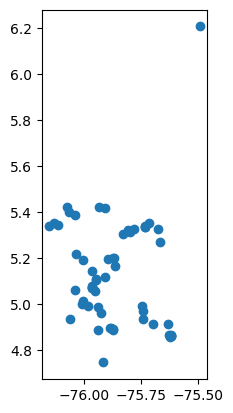

In [ ]:
gdf.plot()

Podemos hacerlo muchísimo mejor

In [ ]:
!pip install contextily
import contextily as cx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 46.1 MB/s eta 0:00:00


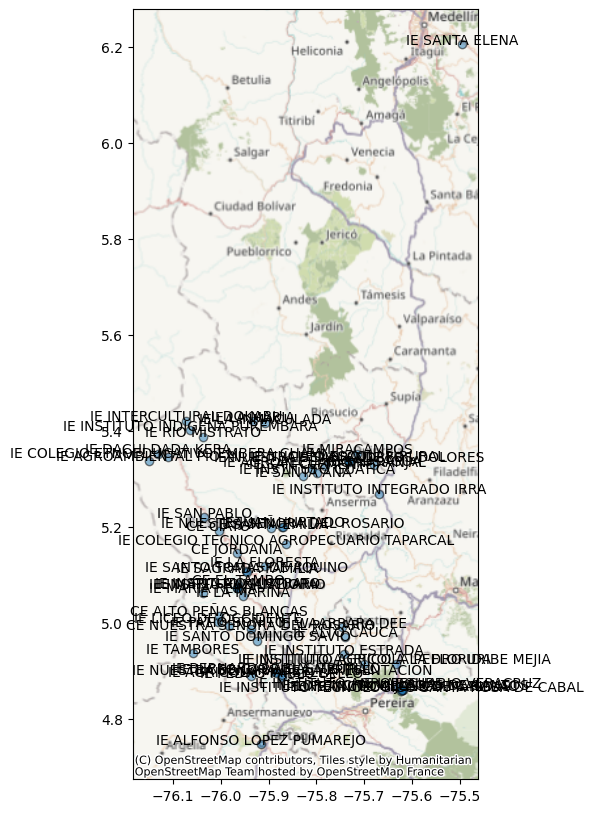

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, alpha=0.5, edgecolor='k')


cx.add_basemap(ax, crs=gdf.crs.to_string())
plt.show()


🔹 Paso 4: Exportación a GeoJSON

In [ ]:
gdf.to_file('Establecimientos_Educativos_Oficiales_20250301.geojson', driver='GeoJSON')

🔹 Paso 5: Visualización Interactiva con Folium

In [ ]:
import folium

# Crear el mapa centrado en Colombia
m = folium.Map(location=[4.5709, -74.2973], zoom_start=6)

m

In [ ]:
# Agregar los puntos al mapa
for _, row in gdf.iterrows():
    folium.Marker(
        location=[row['latitud'], row['longitud']],
        popup=row["nombre"] if "nombre" in gdf.columns else "Establecimiento"
    ).add_to(m)

In [ ]:
# Mostrar el mapa
m